# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`** — EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** — MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [1]:
import struct
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from dataclasses import dataclass, field
from typing import BinaryIO

# ---- Low-level binary readers (mirrors FileIO_Helpers from hreflex_txbdc) ----

TYPE_FMT = {
    'int32': 'i', 'uint64': 'Q', 'uint8': 'B',
    'float32': 'f', 'float64': 'd',
}
TYPE_SIZE = {
    'int32': 4, 'uint64': 8, 'uint8': 1,
    'float32': 4, 'float64': 8,
}

def read_val(fid: BinaryIO, dtype: str):
    raw = fid.read(TYPE_SIZE[dtype])
    if len(raw) < TYPE_SIZE[dtype]:
        raise EOFError(f"Unexpected end of file reading {dtype}")
    return struct.unpack(TYPE_FMT[dtype], raw)[0]

def read_string(fid: BinaryIO) -> str:
    n = read_val(fid, 'int32')
    return fid.read(n).decode('utf-8')

def read_datetime(fid: BinaryIO) -> datetime:
    datenum = read_val(fid, 'float64')
    days = datenum % 1
    return datetime.fromordinal(int(datenum)) + timedelta(days=days) - timedelta(days=366)

def read_array(fid: BinaryIO, dtype: str):
    n = read_val(fid, 'int32')
    fmt = TYPE_FMT[dtype]
    size = TYPE_SIZE[dtype]
    raw = fid.read(n * size)
    return list(struct.unpack(f'{n}{fmt}', raw))

# ---- Block IDs ----
BLOCK_EMG_DATA = 1
BLOCK_EMG_CHAR_TRIAL = 2
BLOCK_MH_TRIAL = 3

# ---- Data classes ----

@dataclass
class EmgCharHeader:
    file_version: int = 0
    subject_id: str = ""
    session_datetime: datetime = datetime.min
    stage_name: str = ""
    stage_description: str = ""
    stage_type: int = 0
    trial_initiation_uv_min: float = 0.0
    trial_initiation_uv_max: float = 0.0
    trial_initiation_phase_min_ms: int = 0
    trial_initiation_phase_max_ms: int = 0
    bin_duration_ms: int = 0

@dataclass
class EmgCharTrial:
    trial_end_datetime: datetime = datetime.min
    trial_start_index: int = 0
    trial_start_open_ephys_millis: int = 0
    trial_start_open_ephys_sample_id: int = 0
    grand_mean: float = 0.0
    bins: list = field(default_factory=list)
    monitored_signal: list = field(default_factory=list)

@dataclass
class EmgDataBlock:
    ts_open_ephys_sent: int = 0
    ts_python_received: int = 0
    ts_background_emitted: int = 0
    channel_names: list = field(default_factory=list)
    raw_channels: list = field(default_factory=list)
    diff: np.ndarray = field(default_factory=lambda: np.array([], dtype=np.float32))
    filtered: np.ndarray = field(default_factory=lambda: np.array([], dtype=np.float32))
    abs_val: np.ndarray = field(default_factory=lambda: np.array([], dtype=np.float32))

@dataclass
class MhRecHeader:
    file_version: int = 0
    subject_id: str = ""
    session_start_time: datetime = datetime.min
    stage_name: str = ""
    stage_description: str = ""
    stage_type: int = 0

@dataclass
class MhRecTrial:
    start_time: datetime = datetime.min
    min_initiation_threshold: float = 0.0
    max_initiation_threshold: float = 0.0
    stimulation_amplitude_ma: float = 0.0
    trial_data: np.ndarray = field(default_factory=lambda: np.array([], dtype=np.float32))

# ---- File readers ----

def read_emg_data_block(fid: BinaryIO) -> EmgDataBlock:
    block = EmgDataBlock()
    block.ts_open_ephys_sent = read_val(fid, 'uint64')
    block.ts_python_received = read_val(fid, 'uint64')
    block.ts_background_emitted = read_val(fid, 'uint64')
    n_names = read_val(fid, 'uint8')
    block.channel_names = [read_string(fid) for _ in range(n_names)]
    n_ch = read_val(fid, 'uint8')
    block.raw_channels = [np.array(read_array(fid, 'float32'), dtype=np.float32) for _ in range(n_ch)]
    block.diff = np.array(read_array(fid, 'float32'), dtype=np.float32)
    block.filtered = np.array(read_array(fid, 'float32'), dtype=np.float32)
    block.abs_val = np.array(read_array(fid, 'float32'), dtype=np.float32)
    return block

def read_mh_trial_block(fid: BinaryIO) -> MhRecTrial:
    t = MhRecTrial()
    t.start_time = read_datetime(fid)
    t.min_initiation_threshold = read_val(fid, 'float32')
    t.max_initiation_threshold = read_val(fid, 'float32')
    t.stimulation_amplitude_ma = read_val(fid, 'float32')
    t.trial_data = np.array(read_array(fid, 'float32'), dtype=np.float32)
    return t

def read_hrs1(filepath: str):
    """Read an .hrs1 (EMG Characterization) data file."""
    header = EmgCharHeader()
    trials = []
    emg_blocks = []

    with open(filepath, 'rb') as fid:
        header.file_version = read_val(fid, 'int32')
        header.subject_id = read_string(fid)
        header.session_datetime = read_datetime(fid)
        header.stage_name = read_string(fid)
        header.stage_description = read_string(fid)
        header.stage_type = read_val(fid, 'int32')
        header.trial_initiation_uv_min = read_val(fid, 'float32')
        header.trial_initiation_uv_max = read_val(fid, 'float32')
        header.trial_initiation_phase_min_ms = read_val(fid, 'int32')
        header.trial_initiation_phase_max_ms = read_val(fid, 'int32')
        header.bin_duration_ms = read_val(fid, 'int32')

        while True:
            chunk = fid.read(4)
            if len(chunk) < 4:
                break
            block_id = struct.unpack('i', chunk)[0]
            if block_id == BLOCK_EMG_CHAR_TRIAL:
                t = EmgCharTrial()
                t.trial_end_datetime = read_datetime(fid)
                t.trial_start_index = read_val(fid, 'uint64')
                t.trial_start_open_ephys_millis = read_val(fid, 'uint64')
                t.trial_start_open_ephys_sample_id = read_val(fid, 'uint64')
                t.grand_mean = read_val(fid, 'float32')
                t.bins = read_array(fid, 'float32')
                t.monitored_signal = read_array(fid, 'float32')
                trials.append(t)
            elif block_id == BLOCK_EMG_DATA:
                emg_blocks.append(read_emg_data_block(fid))

    return header, trials, emg_blocks

def read_hrs2(filepath: str):
    """Read an .hrs2 (MH Recruitment Curve) data file.

    Note: There is a known bug in MhRecruitmentCurveTrial.save_to_file where
    it writes block_id=1 instead of block_id=3. This reader handles both cases
    by attempting to distinguish trial blocks from EMG blocks when block_id=1
    using a peek-ahead heuristic on the first 8 bytes (datetime float64 for
    trials vs uint64 timestamp for EMG).
    """
    header = MhRecHeader()
    trials = []
    emg_blocks = []

    with open(filepath, 'rb') as fid:
        header.file_version = read_val(fid, 'int32')
        header.subject_id = read_string(fid)
        header.session_start_time = read_datetime(fid)
        header.stage_name = read_string(fid)
        header.stage_description = read_string(fid)
        header.stage_type = read_val(fid, 'int32')

        while True:
            chunk = fid.read(4)
            if len(chunk) < 4:
                break
            block_id = struct.unpack('i', chunk)[0]

            if block_id == BLOCK_MH_TRIAL:
                # Block ID 3: this is an MH trial (correct block ID)
                trials.append(read_mh_trial_block(fid))
            elif block_id == BLOCK_EMG_DATA:
                # Block ID 1: could be EMG data OR a trial (due to the bug).
                # Peek at the first 8 bytes to distinguish:
                #   - Trial block: starts with a float64 (MATLAB datenum, typically ~739000-740000)
                #   - EMG block: starts with a uint64 (Unix millis timestamp, typically ~1.7e12)
                pos = fid.tell()
                peek = fid.read(8)
                fid.seek(pos)  # rewind

                if len(peek) < 8:
                    break

                # Interpret as float64 (trial datetime) and uint64 (EMG timestamp)
                peek_float = struct.unpack('d', peek)[0]
                peek_uint = struct.unpack('Q', peek)[0]

                # MATLAB datenums for years 2020-2030 are roughly 737791-741442
                is_likely_datenum = 730000 < peek_float < 750000

                if is_likely_datenum:
                    # This is likely a trial block written with buggy block_id=1
                    trials.append(read_mh_trial_block(fid))
                else:
                    # This is a genuine EMG data block
                    emg_blocks.append(read_emg_data_block(fid))
            else:
                print(f"Warning: unknown block_id={block_id} at file offset {fid.tell()-4}")
                break

    return header, trials, emg_blocks

print("Binary reader utilities loaded.")

Binary reader utilities loaded.


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

In [2]:
# ---- Read the HRS1 file ----
hrs1_path = "H-Reflex APp Recordings/HRPILOT-08_TEST/HRPILOT-08_TEST_20260106T124739.hrs1"

hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)

print(f"=== HRS1 Header ===")
print(f"  File version:       {hrs1_header.file_version}")
print(f"  Subject ID:         {hrs1_header.subject_id}")
print(f"  Session datetime:   {hrs1_header.session_datetime}")
print(f"  Stage name:         {hrs1_header.stage_name}")
print(f"  Stage description:  {hrs1_header.stage_description}")
print(f"  Stage type:         {hrs1_header.stage_type}")
print(f"  Trial init uV min:  {hrs1_header.trial_initiation_uv_min}")
print(f"  Trial init uV max:  {hrs1_header.trial_initiation_uv_max}")
print(f"  Trial init phase min ms: {hrs1_header.trial_initiation_phase_min_ms}")
print(f"  Trial init phase max ms: {hrs1_header.trial_initiation_phase_max_ms}")
print(f"  Bin duration ms:    {hrs1_header.bin_duration_ms}")
print(f"\n  Trials found:       {len(hrs1_trials)}")
print(f"  EMG data blocks:    {len(hrs1_emg_blocks)}")

if len(hrs1_trials) > 0:
    print(f"\n=== First Trial ===")
    t0 = hrs1_trials[0]
    print(f"  End datetime:       {t0.trial_end_datetime}")
    print(f"  Start index:        {t0.trial_start_index}")
    print(f"  Grand mean:         {t0.grand_mean:.4f}")
    print(f"  Bins count:         {len(t0.bins)}")
    print(f"  Monitored signal N: {len(t0.monitored_signal)}")

if len(hrs1_emg_blocks) > 0:
    b0 = hrs1_emg_blocks[0]
    print(f"\n=== First EMG Block ===")
    print(f"  Channel names:      {b0.channel_names}")
    print(f"  Raw channels:       {len(b0.raw_channels)} x {len(b0.raw_channels[0]) if b0.raw_channels else 0} samples")
    print(f"  Diff samples:       {len(b0.diff)}")
    print(f"  Filtered samples:   {len(b0.filtered)}")
    print(f"  Abs samples:        {len(b0.abs_val)}")

=== HRS1 Header ===
  File version:       0
  Subject ID:         HRPILOT-08_TEST
  Session datetime:   2026-01-06 12:47:39.355845
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  5.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50

  Trials found:       50
  EMG data blocks:    3268

=== First Trial ===
  End datetime:       2026-01-06 12:47:41.859472
  Start index:        2672585
  Grand mean:         35.9271
  Bins count:         50
  Monitored signal N: 12500

=== First EMG Block ===
  Channel names:      ['CH7', 'CH8']
  Raw channels:       2 x 191 samples
  Diff samples:       191
  Filtered samples:   191
  Abs samples:        191


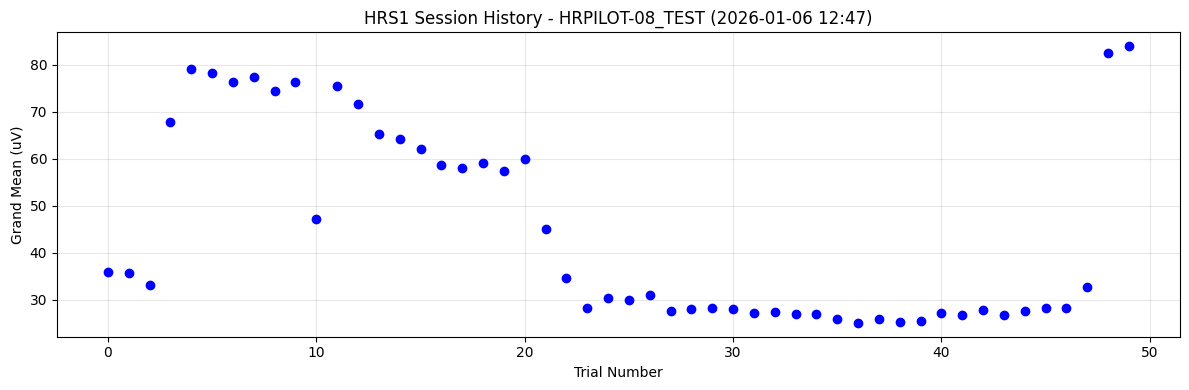

Grand mean range: [25.13, 83.98] uV
Overall mean of grand means: 45.10 uV


In [3]:
# ---- Plot HRS1: Trial Grand Means (Session History) ----
grand_means = [t.grand_mean for t in hrs1_trials]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(grand_means)), grand_means, 'o', color='blue', markersize=6)
ax.set_xlabel('Trial Number')
ax.set_ylabel('Grand Mean (uV)')
ax.set_title(f'HRS1 Session History - {hrs1_header.subject_id} ({hrs1_header.session_datetime:%Y-%m-%d %H:%M})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Grand mean range: [{min(grand_means):.2f}, {max(grand_means):.2f}] uV")
print(f"Overall mean of grand means: {np.mean(grand_means):.2f} uV")

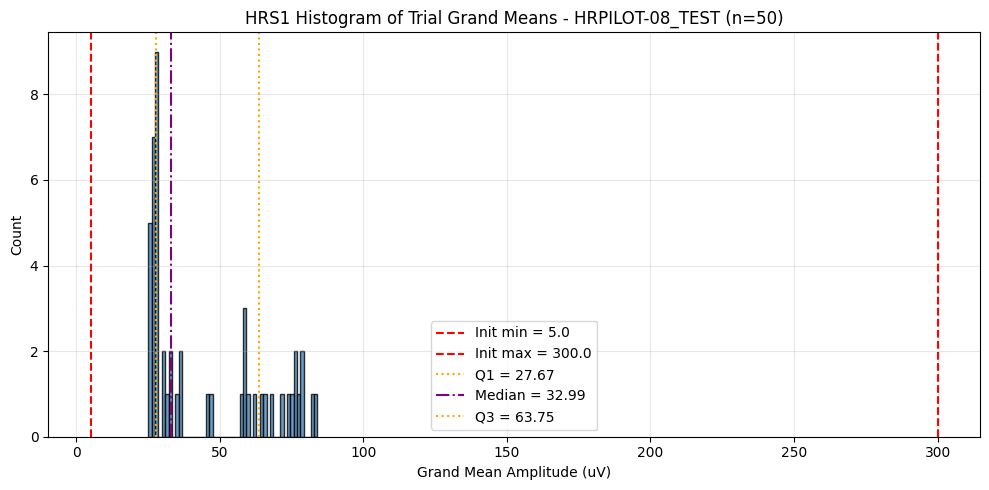

Stats: min=25.13, Q1=27.67, median=32.99, Q3=63.75, max=83.98, std=20.58


In [4]:
# ---- Plot HRS1: Histogram of Grand Means ----
gm = np.array(grand_means)

fig, ax = plt.subplots(figsize=(10, 5))
hist_vals, hist_edges, _ = ax.hist(gm, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(hrs1_header.trial_initiation_uv_min, color='red', linestyle='--', linewidth=1.5, label=f'Init min = {hrs1_header.trial_initiation_uv_min}')
ax.axvline(hrs1_header.trial_initiation_uv_max, color='red', linestyle='--', linewidth=1.5, label=f'Init max = {hrs1_header.trial_initiation_uv_max}')

q25, q50, q75 = np.percentile(gm, [25, 50, 75])
ax.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q1 = {q25:.2f}')
ax.axvline(q50, color='purple', linestyle='-.', linewidth=1.5, label=f'Median = {q50:.2f}')
ax.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q3 = {q75:.2f}')

ax.set_xlabel('Grand Mean Amplitude (uV)')
ax.set_ylabel('Count')
ax.set_title(f'HRS1 Histogram of Trial Grand Means - {hrs1_header.subject_id} (n={len(gm)})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Stats: min={gm.min():.2f}, Q1={q25:.2f}, median={q50:.2f}, Q3={q75:.2f}, max={gm.max():.2f}, std={gm.std():.2f}")

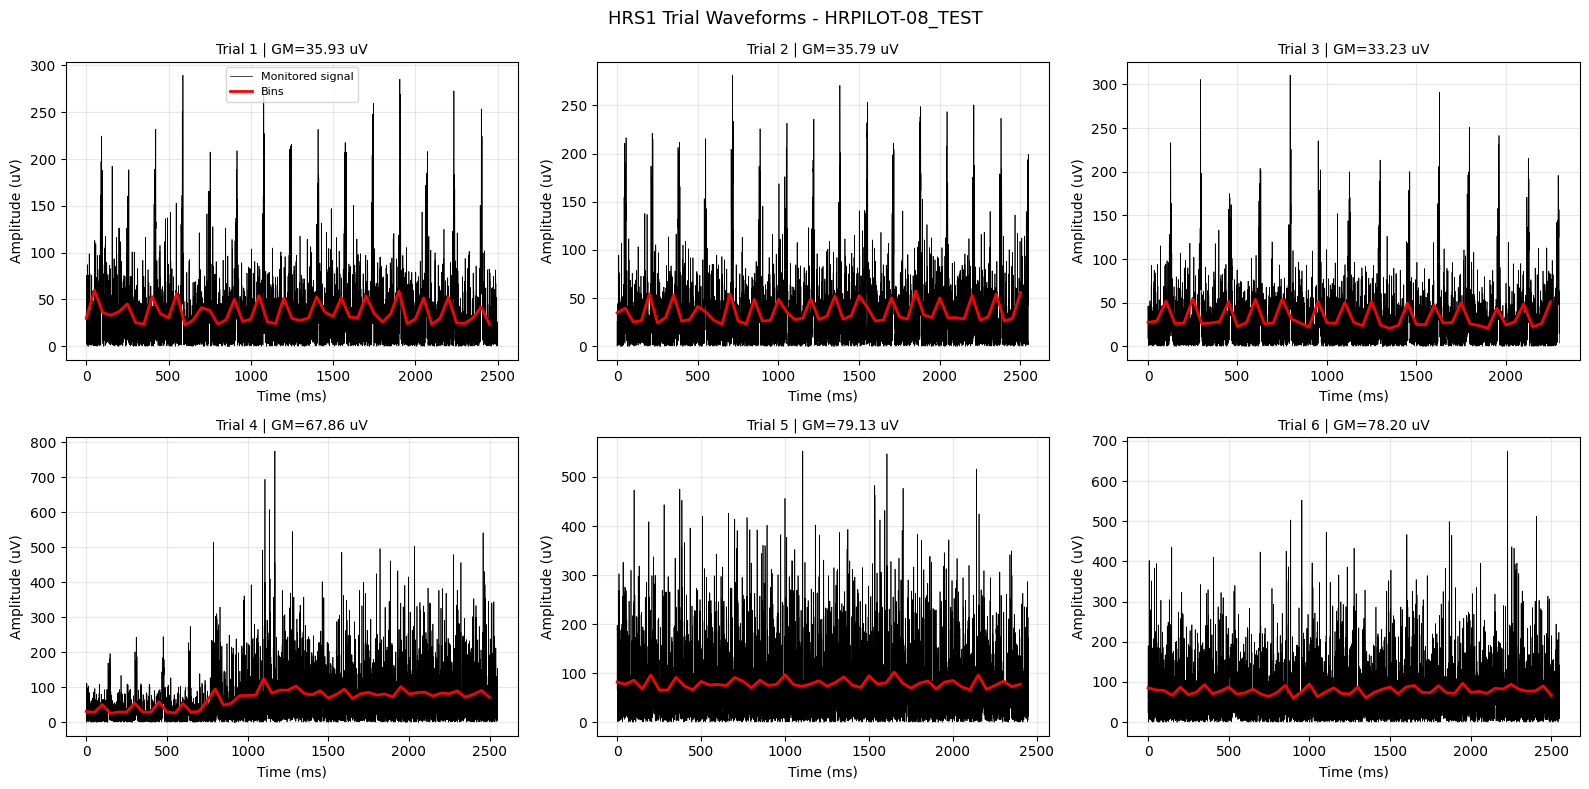

In [5]:
# ---- Plot HRS1: Individual Trial Waveforms (first 6 trials) ----
SAMPLE_RATE = 5000.0  # Hz (from the app)
n_show = min(6, len(hrs1_trials))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    ax = axes[i]
    trial = hrs1_trials[i]
    sig = np.array(trial.monitored_signal)
    bins_arr = np.array(trial.bins)
    bin_sample_count = int((SAMPLE_RATE / 1000) * hrs1_header.bin_duration_ms)

    # Time axis in ms
    t_ms = np.arange(len(sig)) / SAMPLE_RATE * 1000.0

    # Plot monitored signal (abs EMG)
    ax.plot(t_ms, sig, color='black', linewidth=0.5, label='Monitored signal')

    # Plot bins
    bin_x = np.arange(len(bins_arr)) * hrs1_header.bin_duration_ms
    ax.plot(bin_x, bins_arr, color='red', linewidth=2, label='Bins')

    ax.set_title(f'Trial {i+1} | GM={trial.grand_mean:.2f} uV', fontsize=10)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (uV)')
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend(fontsize=8)

for j in range(n_show, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'HRS1 Trial Waveforms - {hrs1_header.subject_id}', fontsize=13)
plt.tight_layout()
plt.show()

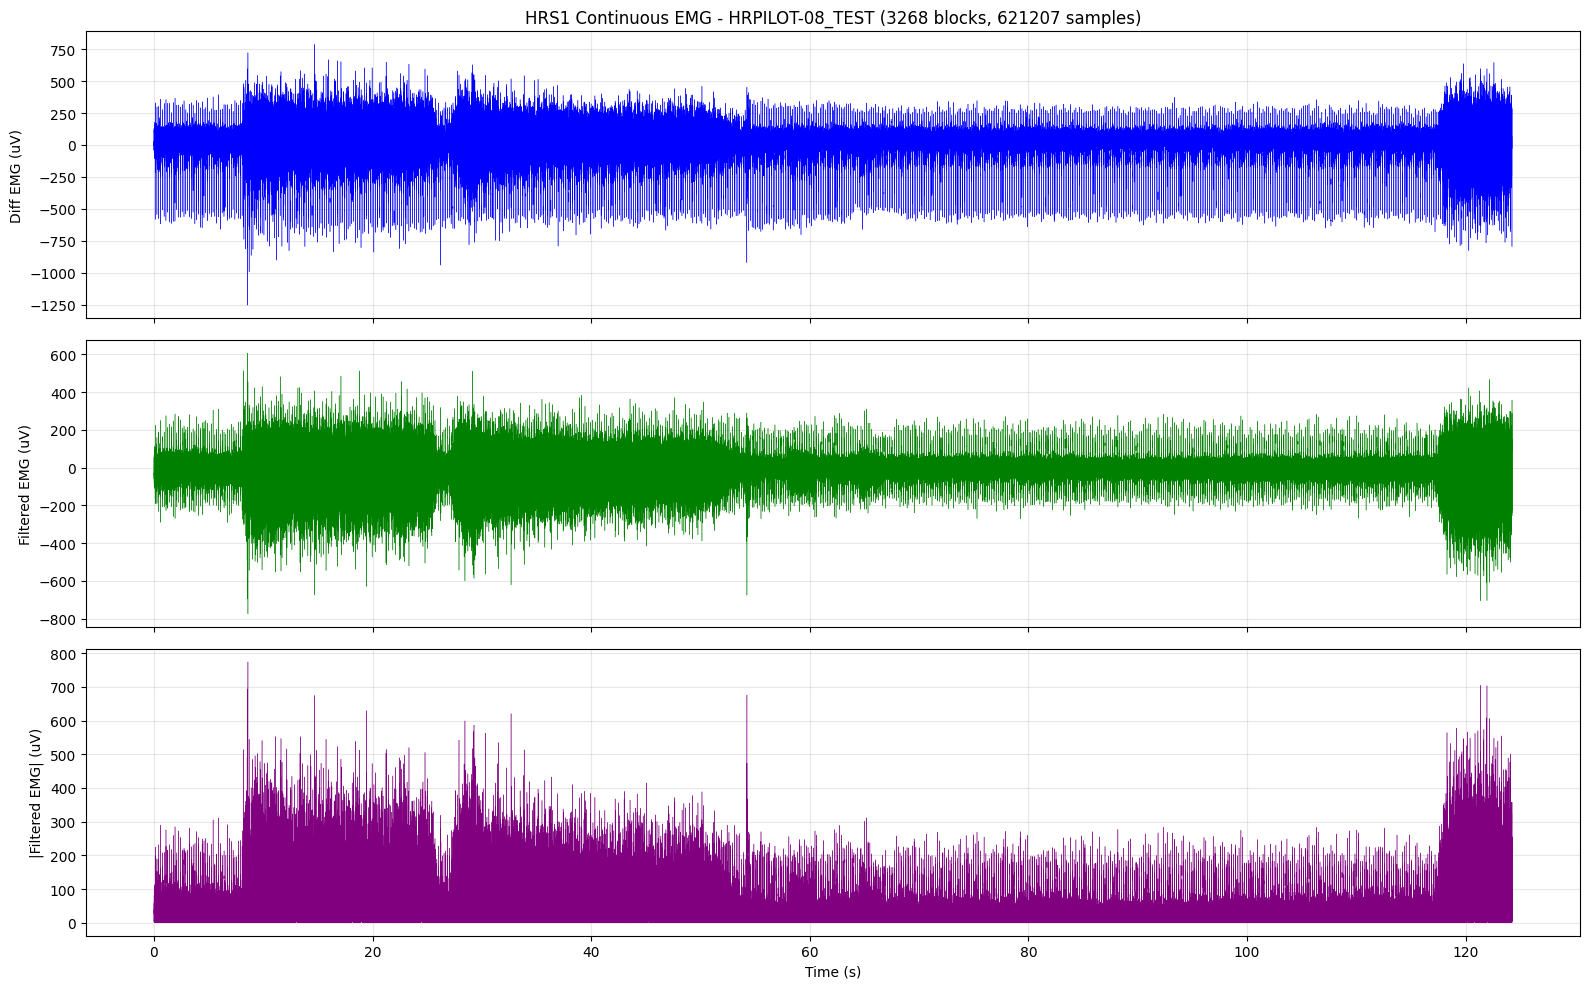

Total continuous samples: 621207, Duration: 124.2 s
Channel names: ['CH7', 'CH8']


In [6]:
# ---- Plot HRS1: Continuous EMG Data (diff, filtered, abs) ----
# Concatenate all EMG blocks to reconstruct the session timeline

if len(hrs1_emg_blocks) > 0:
    all_diff = np.concatenate([b.diff for b in hrs1_emg_blocks])
    all_filt = np.concatenate([b.filtered for b in hrs1_emg_blocks])
    all_abs  = np.concatenate([b.abs_val for b in hrs1_emg_blocks])
    all_ts   = np.array([b.ts_open_ephys_sent for b in hrs1_emg_blocks])

    # Build a sample-level time axis in seconds (relative to session start)
    t_samples = np.arange(len(all_diff)) / SAMPLE_RATE

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(t_samples, all_diff, color='blue', linewidth=0.3)
    axes[0].set_ylabel('Diff EMG (uV)')
    axes[0].set_title(f'HRS1 Continuous EMG - {hrs1_header.subject_id} ({len(hrs1_emg_blocks)} blocks, {len(all_diff)} samples)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_samples, all_filt, color='green', linewidth=0.3)
    axes[1].set_ylabel('Filtered EMG (uV)')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t_samples, all_abs, color='purple', linewidth=0.3)
    axes[2].set_ylabel('|Filtered EMG| (uV)')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Total continuous samples: {len(all_diff)}, Duration: {t_samples[-1]:.1f} s")
    if len(hrs1_emg_blocks[0].channel_names) > 0:
        print(f"Channel names: {hrs1_emg_blocks[0].channel_names}")
else:
    print("No EMG data blocks found in this HRS1 file.")

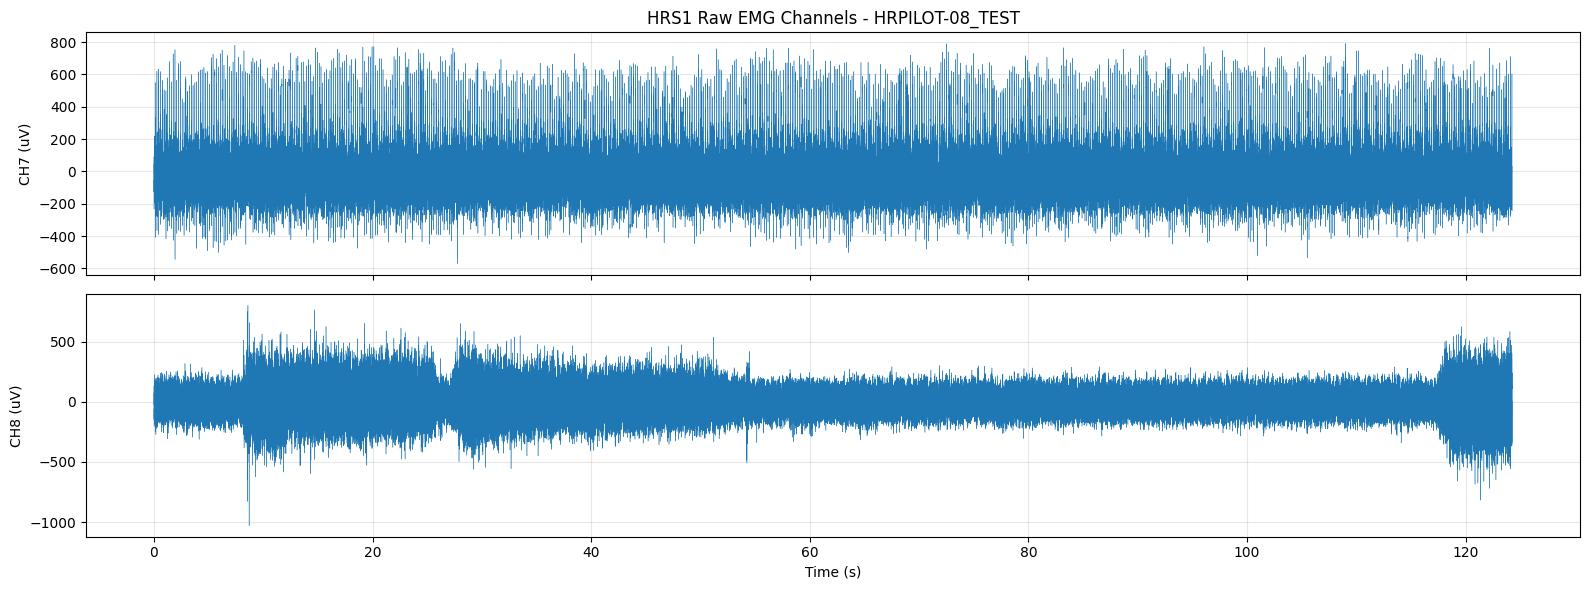

In [7]:
# ---- Plot HRS1: Raw EMG Channels (per-channel overlay) ----
if len(hrs1_emg_blocks) > 0 and len(hrs1_emg_blocks[0].raw_channels) >= 2:
    n_ch = len(hrs1_emg_blocks[0].raw_channels)
    ch_names = hrs1_emg_blocks[0].channel_names if hrs1_emg_blocks[0].channel_names else [f'Ch{i}' for i in range(n_ch)]

    fig, axes = plt.subplots(n_ch, 1, figsize=(16, 3 * n_ch), sharex=True)
    if n_ch == 1:
        axes = [axes]

    for ch_idx in range(n_ch):
        ch_data = np.concatenate([b.raw_channels[ch_idx] for b in hrs1_emg_blocks if len(b.raw_channels) > ch_idx])
        t_ch = np.arange(len(ch_data)) / SAMPLE_RATE
        axes[ch_idx].plot(t_ch, ch_data, linewidth=0.3)
        axes[ch_idx].set_ylabel(f'{ch_names[ch_idx]} (uV)')
        axes[ch_idx].grid(True, alpha=0.3)

    axes[0].set_title(f'HRS1 Raw EMG Channels - {hrs1_header.subject_id}')
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()
else:
    print("No raw channel data available.")

# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [8]:
# ---- Read the HRS2 file ----
hrs2_path = "H-Reflex APp Recordings/HRPILOT-08_TEST/HRPILOT-08_TEST_20260106T124948.hrs2"

hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)

print(f"=== HRS2 Header ===")
print(f"  File version:       {hrs2_header.file_version}")
print(f"  Subject ID:         {hrs2_header.subject_id}")
print(f"  Session start time: {hrs2_header.session_start_time}")
print(f"  Stage name:         {hrs2_header.stage_name}")
print(f"  Stage description:  {hrs2_header.stage_description}")
print(f"  Stage type:         {hrs2_header.stage_type}")
print(f"\n  Trials found:       {len(hrs2_trials)}")
print(f"  EMG data blocks:    {len(hrs2_emg_blocks)}")

if len(hrs2_trials) > 0:
    print(f"\n=== First Trial ===")
    t0 = hrs2_trials[0]
    print(f"  Start time:         {t0.start_time}")
    print(f"  Min init threshold: {t0.min_initiation_threshold:.4f}")
    print(f"  Max init threshold: {t0.max_initiation_threshold:.4f}")
    print(f"  Stim amplitude:     {t0.stimulation_amplitude_ma:.4f} mA")
    print(f"  Trial data length:  {len(t0.trial_data)} samples")

    # Summary of all stim amplitudes
    stim_amps = [t.stimulation_amplitude_ma for t in hrs2_trials]
    unique_amps = sorted(set([round(a, 2) for a in stim_amps]))
    print(f"\n=== Stimulation Summary ===")
    print(f"  Unique amplitudes: {unique_amps}")
    print(f"  Total trials:      {len(hrs2_trials)}")
    for amp in unique_amps:
        count = sum(1 for a in stim_amps if round(a, 2) == amp)
        print(f"    {amp:.2f} mA: {count} trials")
else:
    print("\nNo trials found. The MhRecruitmentCurveTrial.save_to_file may write block_id=1 instead of 3.")
    print("If so, all trial data was misread as EMG blocks.")

if len(hrs2_emg_blocks) > 0:
    b0 = hrs2_emg_blocks[0]
    print(f"\n=== First EMG Block ===")
    print(f"  Channel names:      {b0.channel_names}")
    print(f"  Raw channels:       {len(b0.raw_channels)} x {len(b0.raw_channels[0]) if b0.raw_channels else 0}")
    print(f"  Diff samples:       {len(b0.diff)}")

=== HRS2 Header ===
  File version:       0
  Subject ID:         HRPILOT-08_TEST
  Session start time: 2026-01-06 12:49:48.453102
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       27
  EMG data blocks:    1996

=== First Trial ===
  Start time:         2026-01-06 12:49:50.807535
  Min init threshold: 25.1318
  Max init threshold: 83.9777
  Stim amplitude:     0.1000 mA
  Trial data length:  823 samples

=== Stimulation Summary ===
  Unique amplitudes: [0.0, 0.1, 0.2, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
  Total trials:      27
    0.00 mA: 2 trials
    0.10 mA: 2 trials
    0.20 mA: 1 trials
    0.30 mA: 2 trials
    0.50 mA: 1 trials
    0.60 mA: 1 trials
    0.70 mA: 2 trials
    0.80 mA: 1 trials
    0.90 mA: 1 trials
    1.00 mA: 2 trials
    1.10 mA: 1 trials
    1.30 mA: 1 trials
    1.40 mA: 1 trials
    1.50 mA: 1 trials
    1.60 mA: 2 trials
    1.70 mA: 1 trials
    1.

IndexError: index 6 is out of bounds for axis 0 with size 6

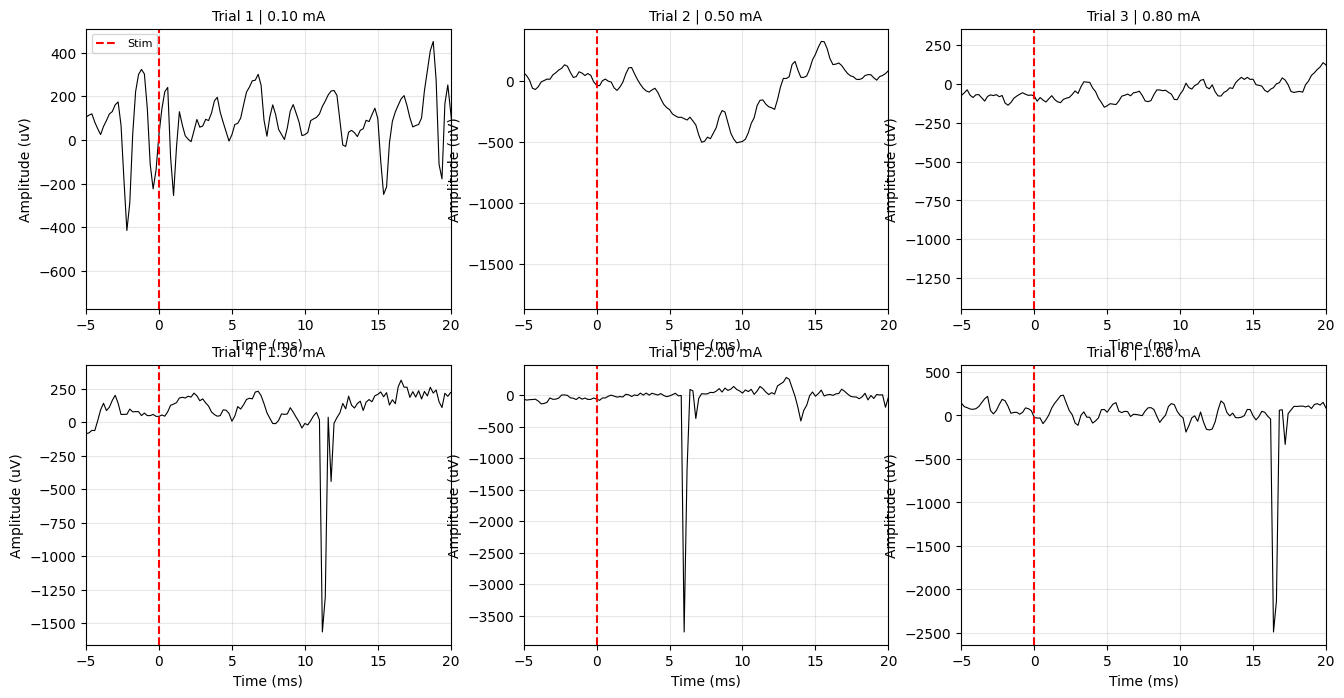

In [ ]:
# ---- Plot HRS2: Individual Trial Waveforms (first 6 trials) ----
MS_PER_SAMPLE = 0.2  # 5000 Hz -> 0.2 ms per sample
PRE_STIM_SAMPLES = 250  # 50 ms pre-stim (one bin)

if len(hrs2_trials) > 0:
    n_show = min(6, len(hrs2_trials))
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(n_show):
        ax = axes[i]
        trial = hrs2_trials[i]
        data = trial.trial_data

        # Time axis: first BIN_SAMPLE_COUNT samples are pre-stim
        t_ms = (np.arange(len(data)) - PRE_STIM_SAMPLES) * MS_PER_SAMPLE

        ax.plot(t_ms, data, color='black', linewidth=0.8)
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Stim')
        ax.set_title(f'Trial {i+1} | {trial.stimulation_amplitude_ma:.2f} mA', fontsize=10)
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Amplitude (uV)')
        ax.set_xlim(-5, 20)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8)

    for j in range(n_show, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'HRS2 Trial Waveforms - {hrs2_header.subject_id}', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No HRS2 trials to plot.")

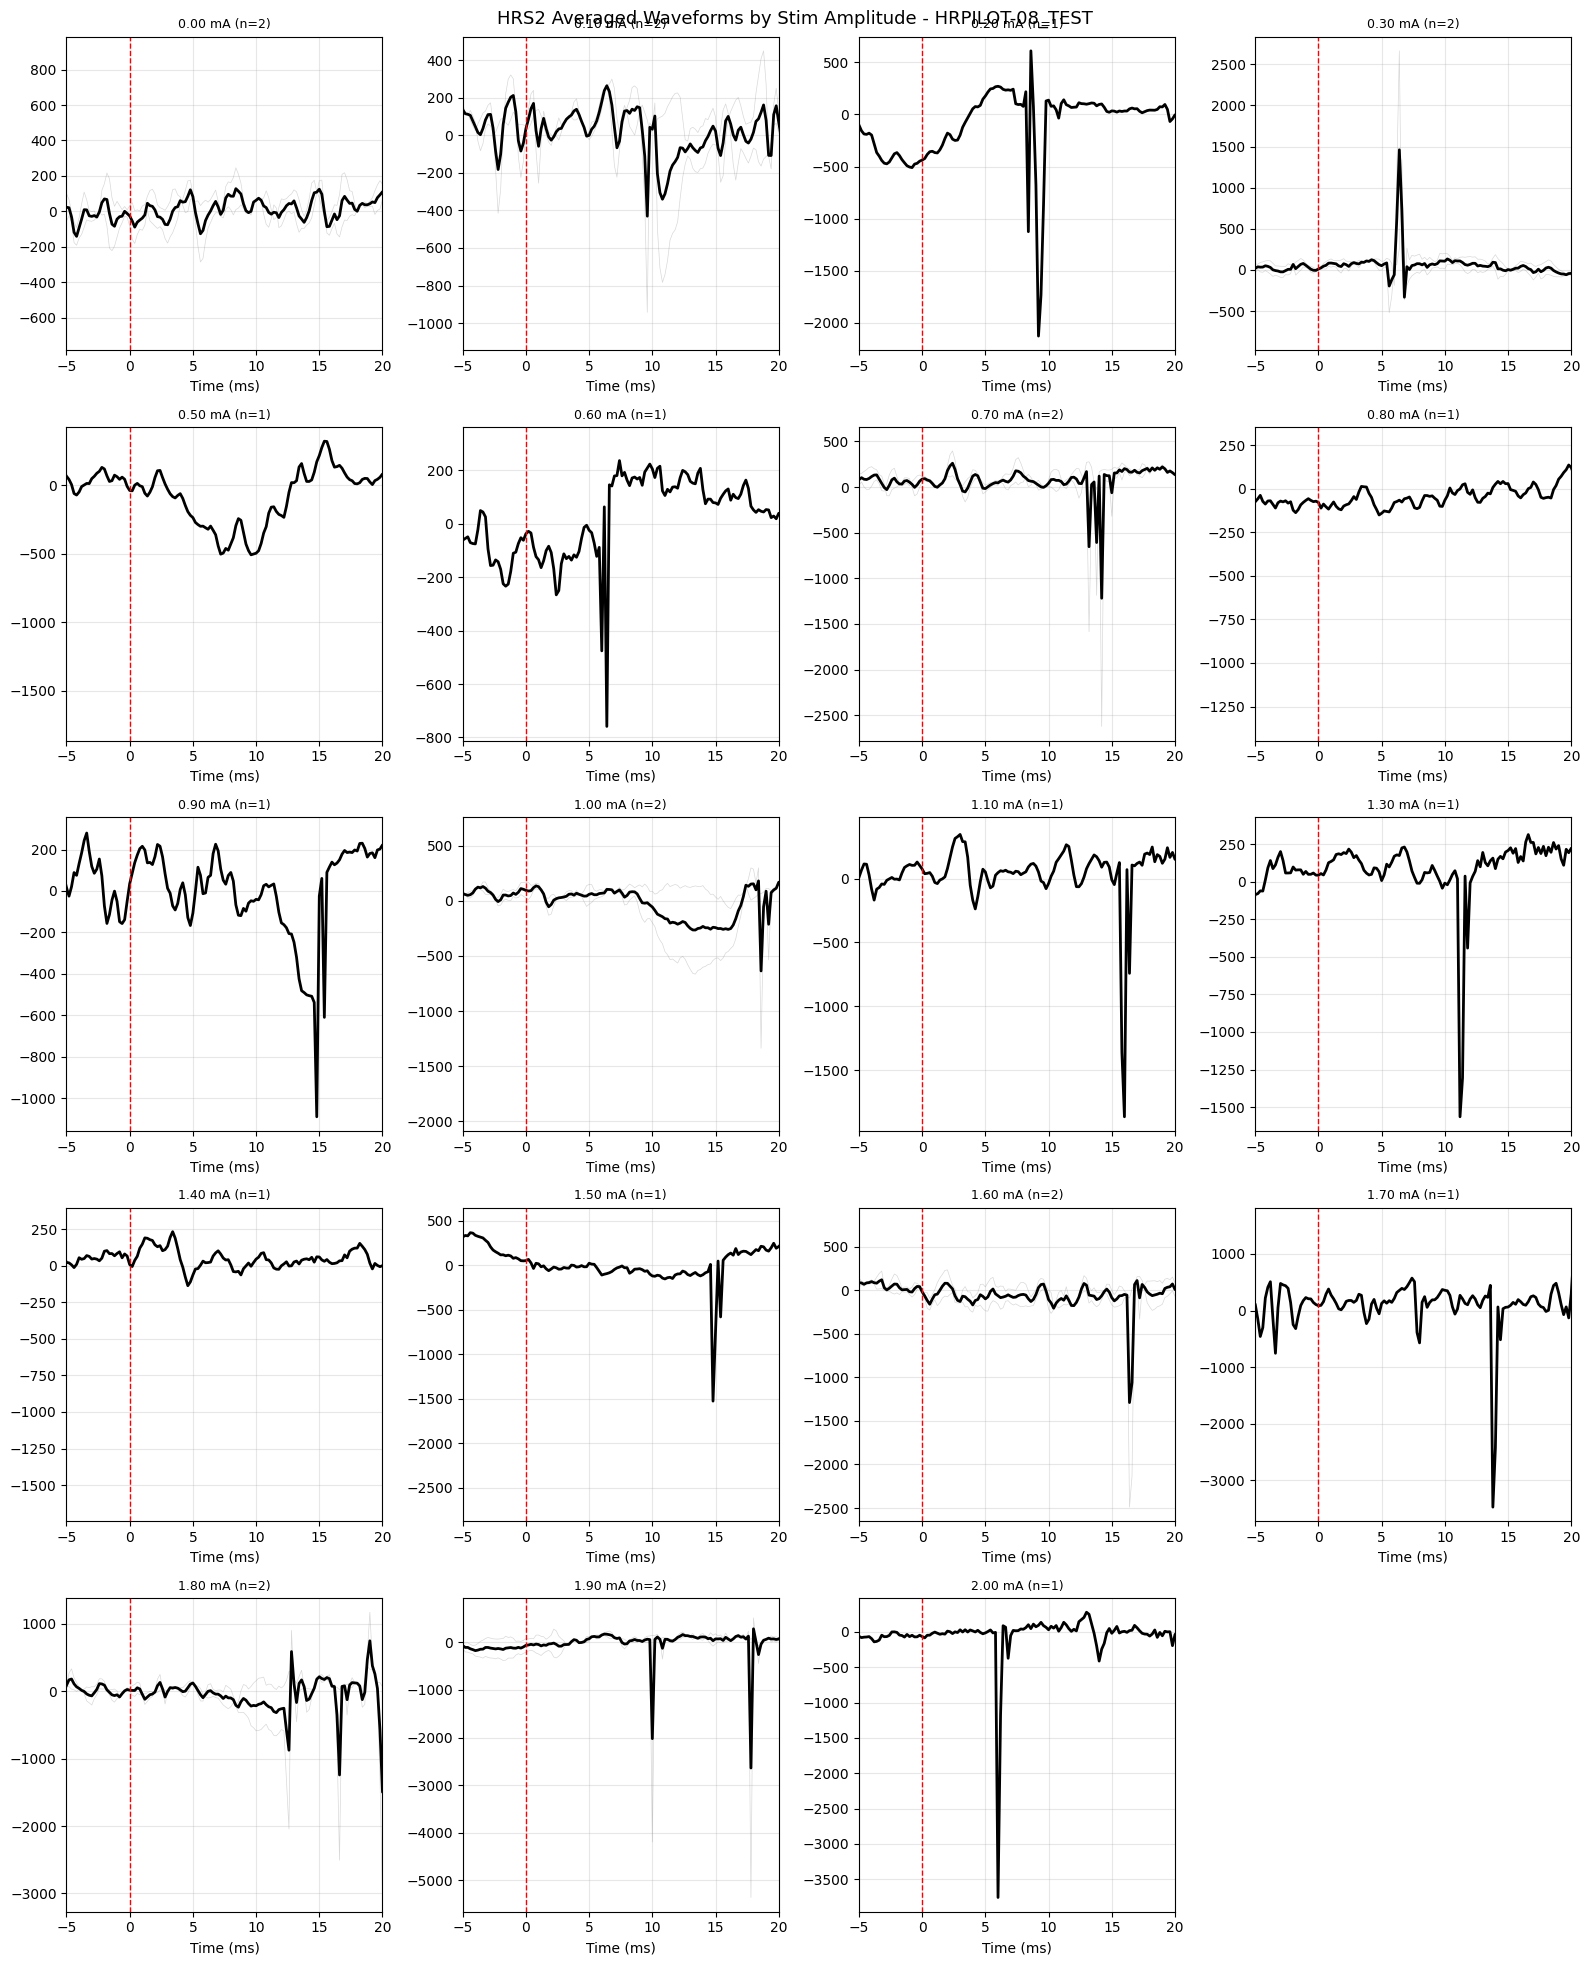

In [10]:
# ---- Plot HRS2: Averaged Waveforms Grouped by Stimulation Amplitude ----
from collections import defaultdict

if len(hrs2_trials) > 0:
    # Group trials by stim amplitude
    groups = defaultdict(list)
    for trial in hrs2_trials:
        key = round(trial.stimulation_amplitude_ma, 2)
        groups[key].append(trial.trial_data)

    sorted_amps = sorted(groups.keys())
    n_groups = len(sorted_amps)
    n_cols = 4
    n_rows = int(np.ceil(n_groups / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).flatten()

    for idx, amp in enumerate(sorted_amps):
        ax = axes[idx]
        waveforms = groups[amp]

        # Pad/truncate to common length
        max_len = max(len(w) for w in waveforms)
        padded = np.full((len(waveforms), max_len), np.nan)
        for k, w in enumerate(waveforms):
            padded[k, :len(w)] = w

        t_ms = (np.arange(max_len) - PRE_STIM_SAMPLES) * MS_PER_SAMPLE
        avg = np.nanmean(padded, axis=0)

        # Plot individual traces faintly
        for row in padded:
            ax.plot(t_ms, row, color='gray', alpha=0.3, linewidth=0.5)

        # Plot average
        ax.plot(t_ms, avg, color='black', linewidth=2)
        ax.axvline(0, color='red', linestyle='--', linewidth=1)
        ax.set_title(f'{amp:.2f} mA (n={len(waveforms)})', fontsize=9)
        ax.set_xlim(-5, 20)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Time (ms)')

    for j in range(n_groups, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'HRS2 Averaged Waveforms by Stim Amplitude - {hrs2_header.subject_id}', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No HRS2 trials to group.")

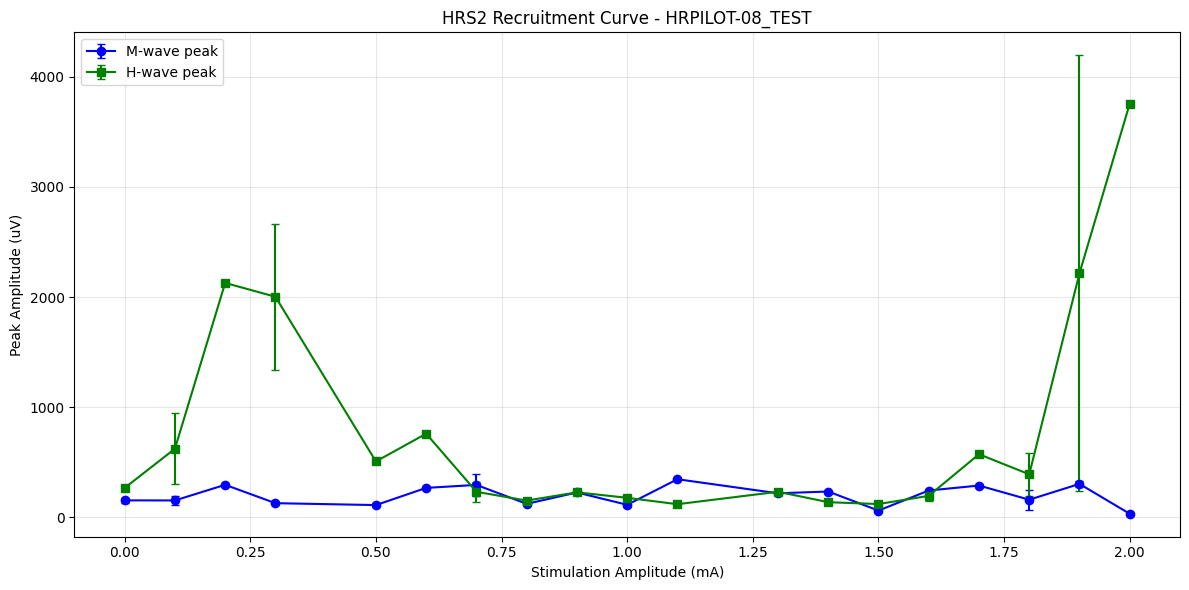

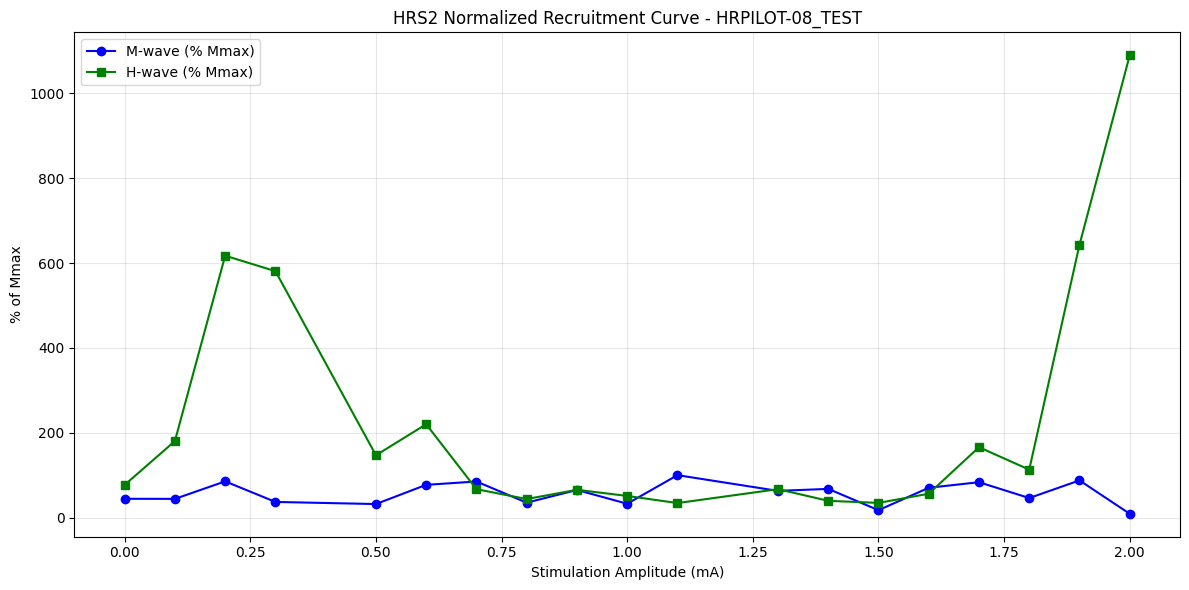

M_max = 344.76 uV
H_max = 3756.48 uV (1089.6% of M_max)


In [11]:
# ---- Plot HRS2: Recruitment Curve (M-wave and H-wave peak amplitudes) ----
# M-wave window: ~1.5-4 ms post-stim, H-wave window: ~4.5-10 ms post-stim

M_WAVE_START_MS = 1.5
M_WAVE_END_MS = 4.0
H_WAVE_START_MS = 4.5
H_WAVE_END_MS = 10.0

if len(hrs2_trials) > 0:
    m_peaks_by_amp = defaultdict(list)
    h_peaks_by_amp = defaultdict(list)

    for trial in hrs2_trials:
        data = trial.trial_data
        t_ms = (np.arange(len(data)) - PRE_STIM_SAMPLES) * MS_PER_SAMPLE
        amp_key = round(trial.stimulation_amplitude_ma, 2)

        # M-wave peak
        m_mask = (t_ms >= M_WAVE_START_MS) & (t_ms <= M_WAVE_END_MS)
        if np.any(m_mask):
            m_peaks_by_amp[amp_key].append(np.max(np.abs(data[m_mask])))

        # H-wave peak
        h_mask = (t_ms >= H_WAVE_START_MS) & (t_ms <= H_WAVE_END_MS)
        if np.any(h_mask):
            h_peaks_by_amp[amp_key].append(np.max(np.abs(data[h_mask])))

    rc_amps = sorted(set(m_peaks_by_amp.keys()) | set(h_peaks_by_amp.keys()))
    m_means = np.array([np.mean(m_peaks_by_amp.get(a, [0])) for a in rc_amps])
    h_means = np.array([np.mean(h_peaks_by_amp.get(a, [0])) for a in rc_amps])

    import scipy.stats as stats
    m_sems = np.array([stats.sem(m_peaks_by_amp[a]) if len(m_peaks_by_amp.get(a, [])) > 1 else 0 for a in rc_amps])
    h_sems = np.array([stats.sem(h_peaks_by_amp[a]) if len(h_peaks_by_amp.get(a, [])) > 1 else 0 for a in rc_amps])

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.errorbar(rc_amps, m_means, yerr=m_sems, fmt='o-', color='blue', label='M-wave peak', capsize=3)
    ax.errorbar(rc_amps, h_means, yerr=h_sems, fmt='s-', color='green', label='H-wave peak', capsize=3)
    ax.set_xlabel('Stimulation Amplitude (mA)')
    ax.set_ylabel('Peak Amplitude (uV)')
    ax.set_title(f'HRS2 Recruitment Curve - {hrs2_header.subject_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Normalized recruitment curve
    M_max = np.max(m_means) if np.max(m_means) > 0 else 1
    m_norm = (m_means / M_max) * 100
    h_norm = (h_means / M_max) * 100

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(rc_amps, m_norm, 'o-', color='blue', label='M-wave (% Mmax)')
    ax.plot(rc_amps, h_norm, 's-', color='green', label='H-wave (% Mmax)')
    ax.set_xlabel('Stimulation Amplitude (mA)')
    ax.set_ylabel('% of Mmax')
    ax.set_title(f'HRS2 Normalized Recruitment Curve - {hrs2_header.subject_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"M_max = {M_max:.2f} uV")
    print(f"H_max = {np.max(h_means):.2f} uV ({np.max(h_norm):.1f}% of M_max)")
else:
    print("No HRS2 trials available for recruitment curve.")

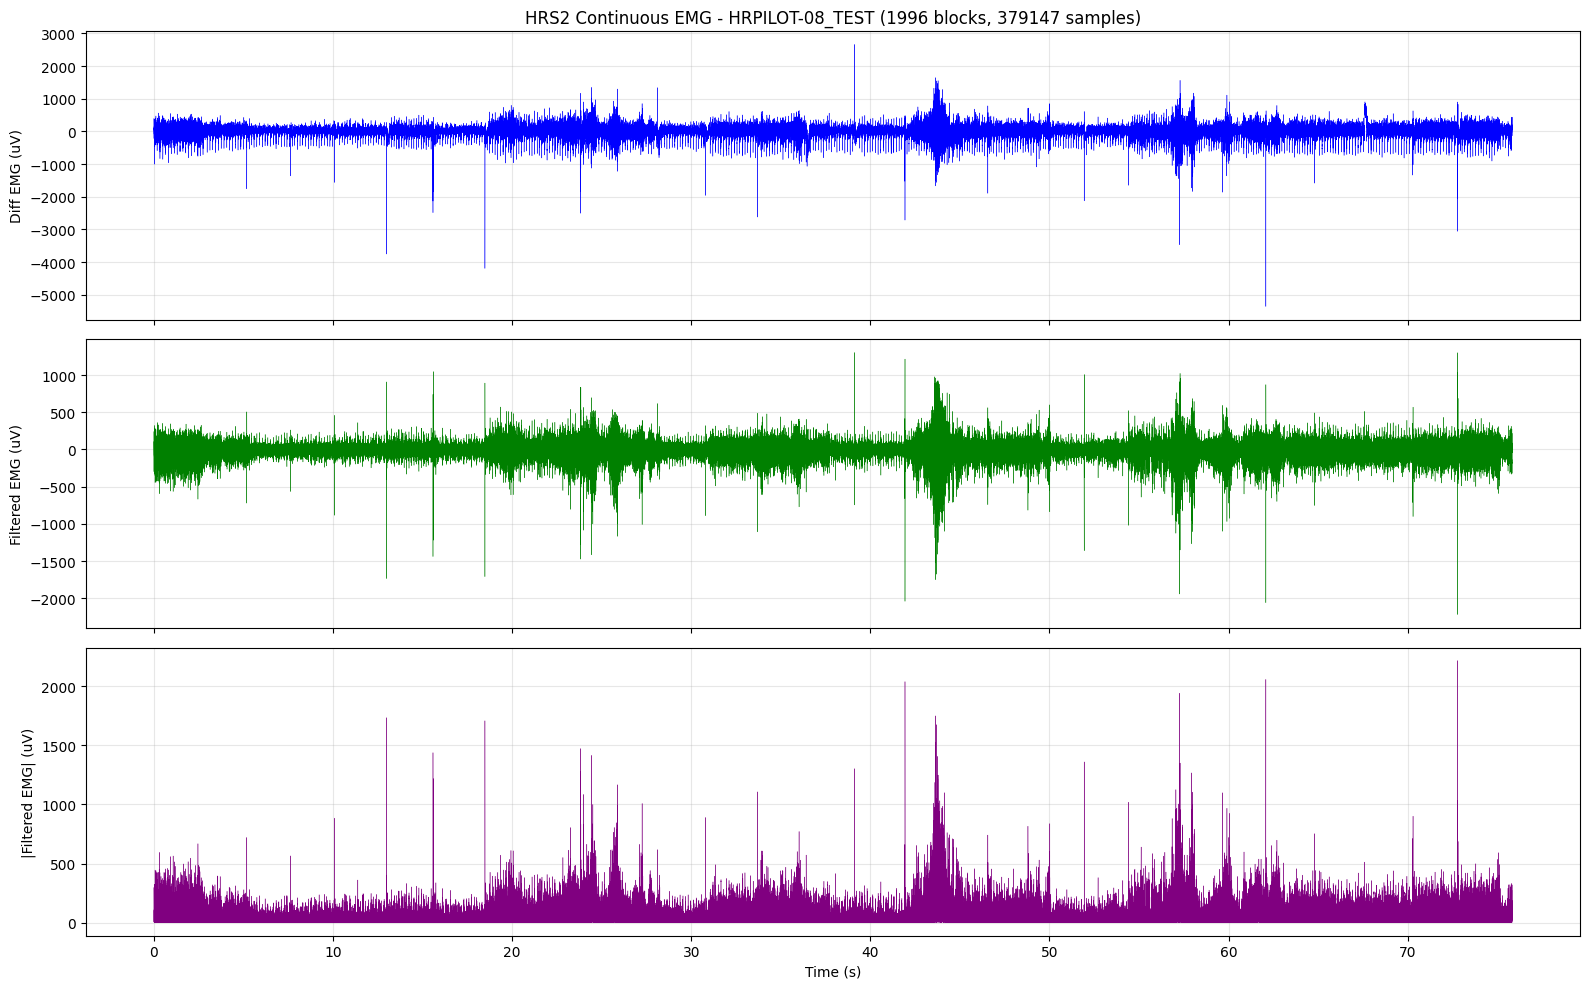

Total continuous samples: 379147, Duration: 75.8 s


In [12]:
# ---- Plot HRS2: Continuous EMG Data ----
if len(hrs2_emg_blocks) > 0:
    all_diff_s2 = np.concatenate([b.diff for b in hrs2_emg_blocks])
    all_filt_s2 = np.concatenate([b.filtered for b in hrs2_emg_blocks])
    all_abs_s2  = np.concatenate([b.abs_val for b in hrs2_emg_blocks])

    t_s2 = np.arange(len(all_diff_s2)) / SAMPLE_RATE

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(t_s2, all_diff_s2, color='blue', linewidth=0.3)
    axes[0].set_ylabel('Diff EMG (uV)')
    axes[0].set_title(f'HRS2 Continuous EMG - {hrs2_header.subject_id} ({len(hrs2_emg_blocks)} blocks, {len(all_diff_s2)} samples)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_s2, all_filt_s2, color='green', linewidth=0.3)
    axes[1].set_ylabel('Filtered EMG (uV)')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t_s2, all_abs_s2, color='purple', linewidth=0.3)
    axes[2].set_ylabel('|Filtered EMG| (uV)')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Total continuous samples: {len(all_diff_s2)}, Duration: {t_s2[-1]:.1f} s")
else:
    print("No EMG data blocks found in this HRS2 file.")